In [ ]:
from typing import List, Tuple, Dict, Union, Optional, Any, Set, Callable

## Prefix Sum

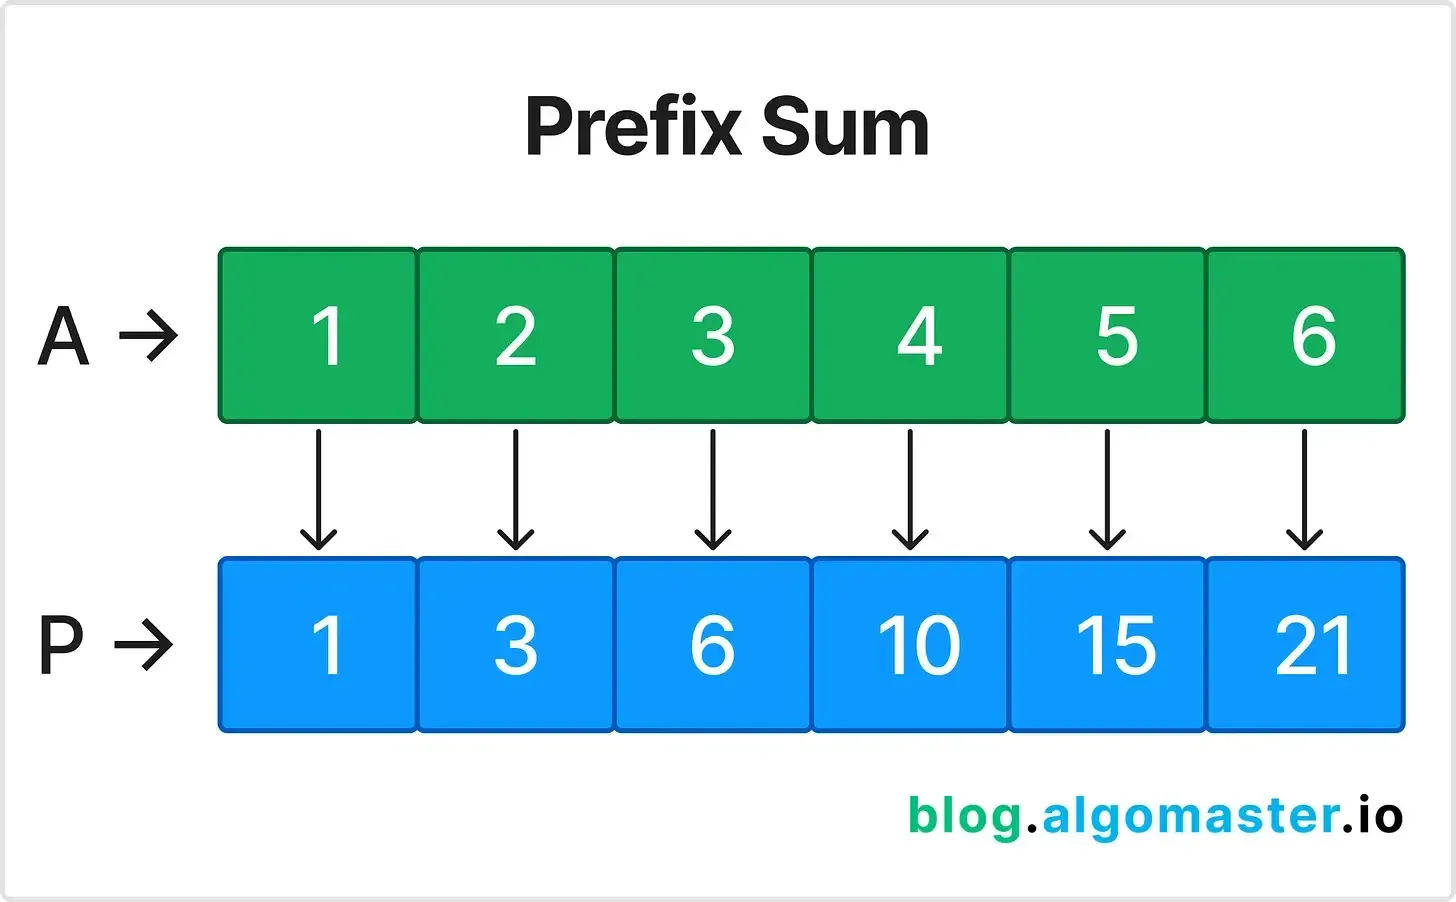

Prefix Sum involves preprocessing an array to create a new array where each element at index i represents the sum of the array from the start up to i. This allows for efficient sum queries on subarrays.

Use this pattern when you need to perform multiple sum queries on a subarray or need to calculate cumulative sums.

Q. Given an integer array nums, handle multiple queries of the following type:

Calculate the sum of the elements of nums between indices left and right inclusive where left <= right.
Implement the NumArray class:

NumArray(int[] nums) Initializes the object with the integer array nums.
int sumRange(int left, int right) Returns the sum of the elements of nums between indices left and right inclusive (i.e. nums[left] + nums[left + 1] + ... + nums[right]).

Example 1:

Input
["NumArray", "sumRange", "sumRange", "sumRange"]
[[[-2, 0, 3, -5, 2, -1]], [0, 2], [2, 5], [0, 5]]
Output
[null, 1, -1, -3]

Explanation
NumArray numArray = new NumArray([-2, 0, 3, -5, 2, -1]);
numArray.sumRange(0, 2); // return (-2) + 0 + 3 = 1
numArray.sumRange(2, 5); // return 3 + (-5) + 2 + (-1) = -1
numArray.sumRange(0, 5); // return (-2) + 0 + 3 + (-5) + 2 + (-1) = -3
 

Constraints:

1 <= nums.length <= 104
-105 <= nums[i] <= 105
0 <= left <= right < nums.length
At most 104 calls will be made to sumRange.

https://leetcode.com/problems/range-sum-query-immutable/

In [ ]:
class NumArray:

    def __init__(self, nums: list[int]):
        self.arr = nums
        self.cum_sum_arr = []
        # cum_sum = 0
        # for num in nums:
        #     cum_sum += num
        #     self.cum_sum_arr.append(cum_sum)
        #     print(self.cum_sum_arr)
        self.cum_sum_arr = [sum(nums[: i+1]) for i in range(len(nums))]

    def sumRange(self, left: int, right: int) -> int:
        # right = min(len(self.cum_sum_arr) -1, right)
        if left == 0:
            # print(f"{left=}, {right=}, {self.cum_sum_arr[right]}")
            return self.cum_sum_arr[right]

        # print(f"{left=}, {right=}, {self.cum_sum_arr[right] - self.cum_sum_arr[left]}")
        return self.cum_sum_arr[right] - self.cum_sum_arr[left - 1]


# Your NumArray object will be instantiated and called as such:
# obj = NumArray(nums)
# param_1 = obj.sumRange(left,right)

Q. Given a binary array nums, return the maximum length of a contiguous subarray with an equal number of 0 and 1.

Example 1:

Input: nums = [0,1]
Output: 2
Explanation: [0, 1] is the longest contiguous subarray with an equal number of 0 and 1.
Example 2:

Input: nums = [0,1,0]
Output: 2
Explanation: [0, 1] (or [1, 0]) is a longest contiguous subarray with equal number of 0 and 1.
Example 3:

Input: nums = [0,1,1,1,1,1,0,0,0]
Output: 6
Explanation: [1,1,1,0,0,0] is the longest contiguous subarray with equal number of 0 and 1.
 

https://leetcode.com/problems/contiguous-array/

In [ ]:
class Solution:
    def findMaxLength(self, nums: list[int]) -> int:
        first_idx_map = {}  # the 1st index of a particular sum occurs
        max_len = 0
        cum_sum = 0
        for i, el in enumerate(nums):
            cum_sum += -1 if el == 0 else 1
            if cum_sum not in first_idx_map:
                first_idx_map[cum_sum] = i

            if cum_sum == 0:
                max_len = max(max_len, i + 1)
            elif cum_sum in first_idx_map:
                max_len = max(max_len, i - first_idx_map[cum_sum])
            
        return max_len
            
        

Q. Given an array of integers nums and an integer k, return the total number of subarrays whose sum equals to k.

A subarray is a contiguous non-empty sequence of elements within an array.

 

Example 1:

Input: nums = [1,1,1], k = 2
Output: 2
Example 2:

Input: nums = [1,2,3], k = 3
Output: 2
 

Constraints:

1 <= nums.length <= 2 * 104
-1000 <= nums[i] <= 1000
-107 <= k <= 107

https://leetcode.com/problems/contiguous-array/description/

In [ ]:
class Solution:
    # O(n^2) solution
    def subarraySumOsq(self, nums: list[int], k: int) -> int:
        count = 0
        for i in range(len(nums)):
            cum_sum = 0
            for j, el in enumerate(nums[i:]):
                cum_sum += el

                if cum_sum == k:
                    count += 1
                
        return count

    # O(n) solution
    def subarraySum(self, nums: list[int], k: int) -> int:
        cum_sum = 0
        count = 0
        cum_sum_counts = {0: 1}

        for i, num in enumerate(nums):
            cum_sum += num

            init_cum_sum = cum_sum  - k
            if init_cum_sum in cum_sum_counts:
                count += cum_sum_counts[init_cum_sum]

            cum_sum_counts[cum_sum] = cum_sum_counts.get(cum_sum, 0) + 1
        
        return count

            
        return count

## Two Pointers

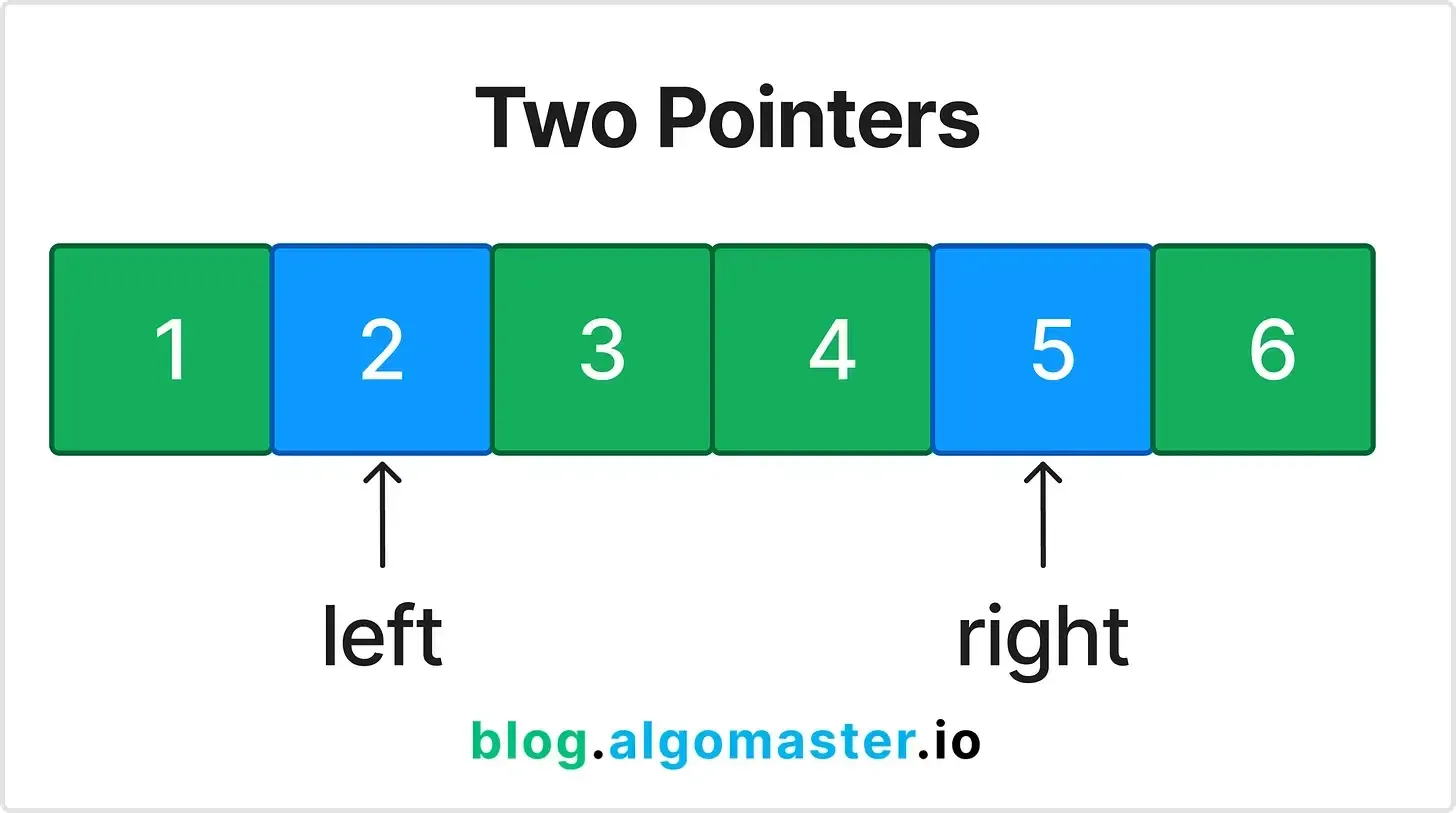

The Two Pointers pattern involves using two pointers to iterate through an array or list, often used to find pairs or elements that meet specific criteria.

Use this pattern when dealing with sorted arrays or lists where you need to find pairs that satisfy a specific condition.

Q. Given a 1-indexed array of integers numbers that is already sorted in non-decreasing order, find two numbers such that they add up to a specific target number. Let these two numbers be numbers[index1] and numbers[index2] where 1 <= index1 < index2 <= numbers.length.

Return the indices of the two numbers, index1 and index2, added by one as an integer array [index1, index2] of length 2.

The tests are generated such that there is exactly one solution. You may not use the same element twice.

Your solution must use only constant extra space.

 

Example 1:

Input: numbers = [2,7,11,15], target = 9
Output: [1,2]
Explanation: The sum of 2 and 7 is 9. Therefore, index1 = 1, index2 = 2. We return [1, 2].
Example 2:

Input: numbers = [2,3,4], target = 6
Output: [1,3]
Explanation: The sum of 2 and 4 is 6. Therefore index1 = 1, index2 = 3. We return [1, 3].
Example 3:

Input: numbers = [-1,0], target = -1
Output: [1,2]
Explanation: The sum of -1 and 0 is -1. Therefore index1 = 1, index2 = 2. We return [1, 2]

https://leetcode.com/problems/two-sum-ii-input-array-is-sorted/description/

In [ ]:
class Solution:
    def twoSum(self, numbers: List[int], target: int) -> List[int]:
        left = 0
        right = len(numbers) - 1

        # while True:
        for _ in range(len(numbers)):
            if left >= right:
                return []
            
            if numbers[left] + numbers[right] == target:
                return [left + 1, right + 1]
            elif numbers[left] + numbers[right] > target:
                right -= 1
            else:
                left += 1
        return []

Q. Given an integer array nums, return all the triplets [nums[i], nums[j], nums[k]] such that i != j, i != k, and j != k, and nums[i] + nums[j] + nums[k] == 0.

Notice that the solution set must not contain duplicate triplets.

 

Example 1:

Input: nums = [-1,0,1,2,-1,-4]
Output: [[-1,-1,2],[-1,0,1]]
Explanation: 
nums[0] + nums[1] + nums[2] = (-1) + 0 + 1 = 0.
nums[1] + nums[2] + nums[4] = 0 + 1 + (-1) = 0.
nums[0] + nums[3] + nums[4] = (-1) + 2 + (-1) = 0.
The distinct triplets are [-1,0,1] and [-1,-1,2].
Notice that the order of the output and the order of the triplets does not matter.
Example 2:

Input: nums = [0,1,1]
Output: []
Explanation: The only possible triplet does not sum up to 0.
Example 3:

Input: nums = [0,0,0]
Output: [[0,0,0]]
Explanation: The only possible triplet sums up to 0.
 

Constraints:

3 <= nums.length <= 3000
-105 <= nums[i] <= 105
 

https://leetcode.com/problems/3sum/description/

In [ ]:
class Solution:
    # Inefficient way
    def threeSum1(self, nums: List[int]) -> List[List[int]]:
        l = len(nums)
        i = 0
        j = l // 3
        k = (l // 3) * 2
        res = []
        ele_str_map = {}
        
        for i in range(0, l - 2):
            for j in range(i + 1, l - 1):
                for k in range(j + 1, l):
                    if nums[i] + nums[j] + nums[k] == 0:
                        ele = sorted([nums[i], nums[j], nums[k]])
                        ele_str = "".join([str(x) for x in ele])
                        if ele_str not in ele_str_map:
                            res.append(ele)
                            ele_str_map[ele_str] = True

        return res

    # Efficient way
    def threeSum(self, nums: List[int]) -> List[List[int]]:
        l = len(nums)
        i = 0
        j = l // 3
        k = (l // 3) * 2
        res = []
        ele_str_map = {}

        nums = sorted(nums)

        if not (nums[0] <= 0 and nums[-1] >= 0):
            return res
        elif nums[0] == nums[-1] == 0:
            return [[0, 0, 0]]
        
        for i in range(0, l - 2):
            j = i + 1
            k = l - 1
            # while True:
            for _ in range(l):
                if j >= k:
                    break

                ijk_sum =nums[i] + nums[j] + nums[k]
                if ijk_sum == 0:
                    ele = sorted([nums[i], nums[j], nums[k]])
                    ele_str = "".join([str(x) for x in ele])
                    if ele_str not in ele_str_map:
                        res.append(ele)
                        ele_str_map[ele_str] = True
                    # break
                    j += 1

                if ijk_sum < 0:
                    j += 1
                else:
                    k -= 1         
            
        return res

Q. You are given an integer array height of length n. There are n vertical lines drawn such that the two endpoints of the ith line are (i, 0) and (i, height[i]).

Find two lines that together with the x-axis form a container, such that the container contains the most water.

Return the maximum amount of water a container can store.

Notice that you may not slant the container.

 

Example 1:

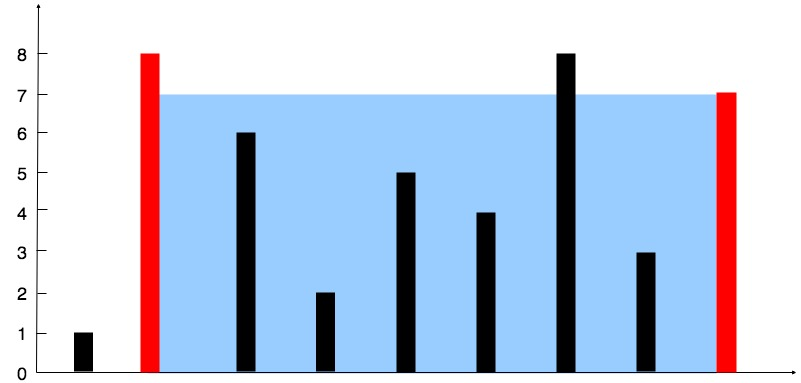


Input: height = [1,8,6,2,5,4,8,3,7]
Output: 49
Explanation: The above vertical lines are represented by array [1,8,6,2,5,4,8,3,7]. In this case, the max area of water (blue section) the container can contain is 49.
Example 2:

Input: height = [1,1]
Output: 1
 

Constraints:

n == height.length
2 <= n <= 105
0 <= height[i] <= 104

In [ ]:
class Solution:
    def maxArea(self, height: List[int]) -> int:
        n = len(height)
        left = 0
        right = (n - 1)
        max_vol = 0
        
        for _ in range(n):
            if left >= right:
                break

            vol = (right - left) * min(height[left], height[right])

            if vol > max_vol:
                max_vol = vol

            if height[left] < height[right]:
                left += 1
            else:
                right -= 1
        
        return max_vol

        

## Sliding Window

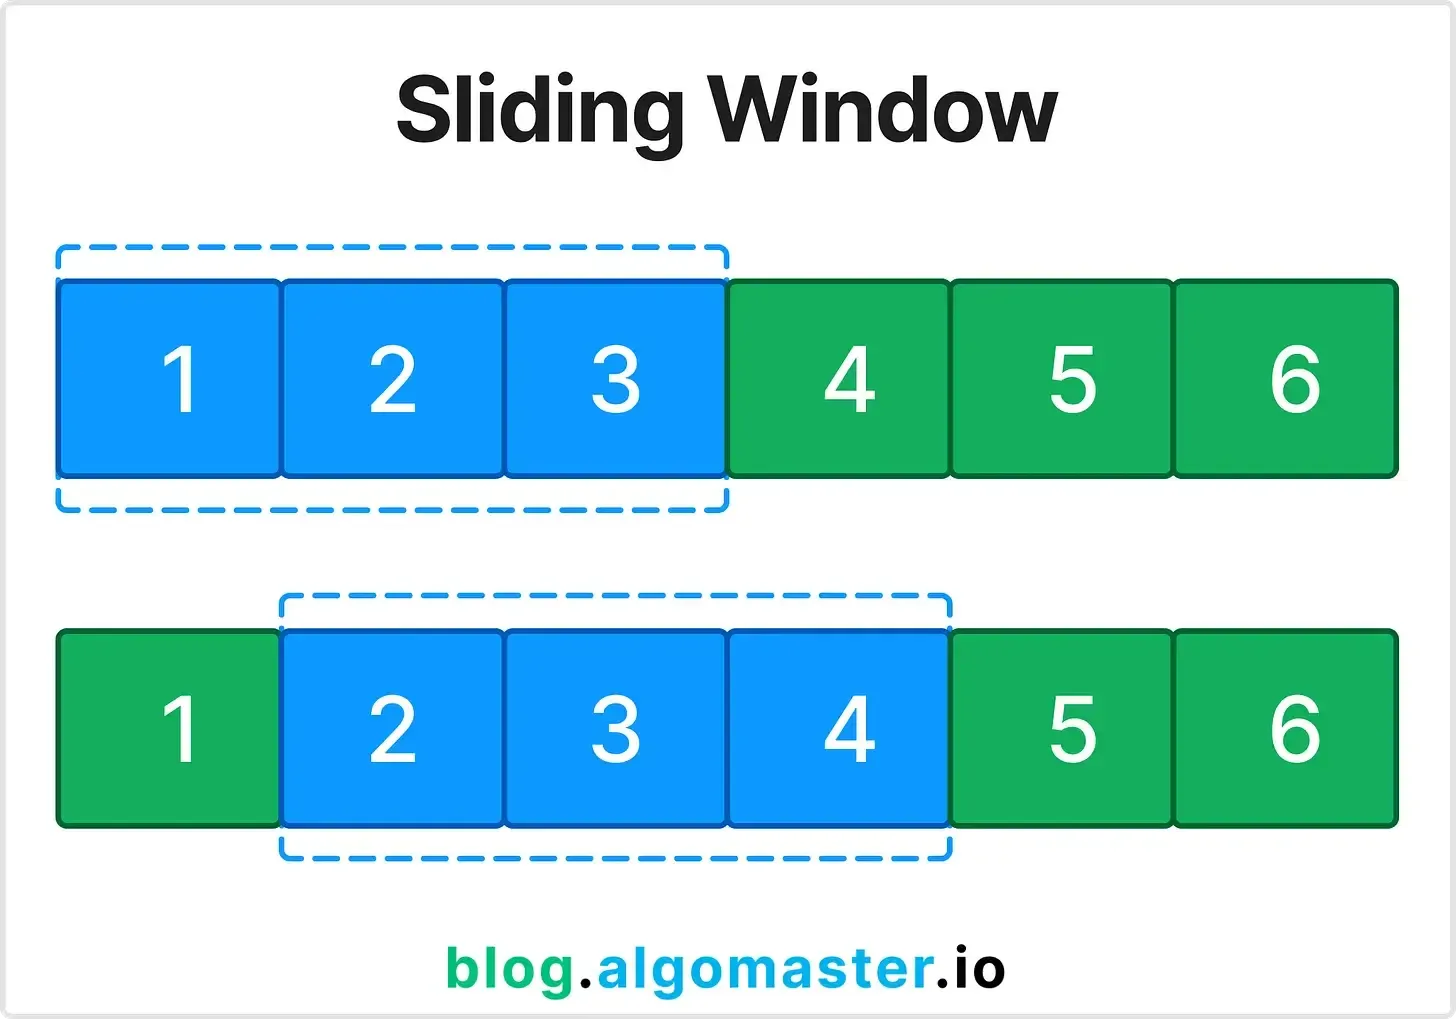

The Sliding Window pattern is used to find a subarray or substring that satisfies a specific condition, optimizing the time complexity by maintaining a window of elements.

Use this pattern when dealing with problems involving contiguous subarrays or substrings.

Sample Problem:
Find the maximum sum of a subarray of size k.

Example:

Input: nums = [2, 1, 5, 1, 3, 2], k = 3

Output: 9

Explanation:
Start with the sum of the first k elements.

Slide the window one element at a time, subtracting the element that goes out of the window and adding the new element.

Keep track of the maximum sum encountered.

Q. You are given an integer array nums consisting of n elements, and an integer k.

Find a contiguous subarray whose length is equal to k that has the maximum average value and return this value. Any answer with a calculation error less than 10-5 will be accepted.

 

Example 1:

Input: nums = [1,12,-5,-6,50,3], k = 4
Output: 12.75000
Explanation: Maximum average is (12 - 5 - 6 + 50) / 4 = 51 / 4 = 12.75
Example 2:

Input: nums = [5], k = 1
Output: 5.00000
 

Constraints:

n == nums.length
1 <= k <= n <= 105
-104 <= nums[i] <= 104

https://leetcode.com/problems/maximum-average-subarray-i/description/

In [ ]:
class Solution:
    def findMaxAverage(self, nums: List[int], k: int) -> float:
        n = len(nums)
        n_iter = n - k + 1
        max_sum = -1e10

        for i in range(n_iter):
            w = nums[i: i+k]

            w_sum = sum(w)

            if w_sum > max_sum:
                max_sum = w_sum

Q. Given a string s, find the length of the longest substring without duplicate characters.

 

Example 1:

Input: s = "abcabcbb"
Output: 3
Explanation: The answer is "abc", with the length of 3. Note that "bca" and "cab" are also correct answers.
Example 2:

Input: s = "bbbbb"
Output: 1
Explanation: The answer is "b", with the length of 1.
Example 3:

Input: s = "pwwkew"
Output: 3
Explanation: The answer is "wke", with the length of 3.
Notice that the answer must be a substring, "pwke" is a subsequence and not a substring.
 

Constraints:

0 <= s.length <= 5 * 104
s consists of English letters, digits, symbols and spaces.

https://leetcode.com/problems/longest-substring-without-repeating-characters/description/

In [ ]:
class Solution:
    def lengthOfLongestSubstring(self, s: str) -> int:
        l = len(s)
        if l == 0:
            return 0
        
        w = s[0]
        wl = len(w)
        max_l = wl
        i = 0
        j = 1
        hit = False
        # while i + max_l < l:
        # while i + len(w) < l:
        for _ in range(len(s)):
            w = s[i: i + j + 1]
            if len(w) == len(set(w)):
                j += 1
                # continue
                hit = False
            else:
                i += 1
                w = s[i: i + j]
                if len(w) > max_l:
                    max_l = len(w)
                    print(s[i-1: i + j], max_l)
                    hit = True
            print(i, j, w, max_l)
        
        if not hit:
            max_l = max(max_l, len(w))
            
        return max_l

In [ ]:
c = Solution()
c.lengthOfLongestSubstring("abcabcbb")
# c.lengthOfLongestSubstring("au")
# c.lengthOfLongestSubstring("dvdf")

Q. Given two strings s and t of lengths m and n respectively, return the minimum window substring of s such that every character in t (including duplicates) is included in the window. If there is no such substring, return the empty string "".

The testcases will be generated such that the answer is unique.

 

Example 1:

Input: s = "ADOBECODEBANC", t = "ABC"
Output: "BANC"
Explanation: The minimum window substring "BANC" includes 'A', 'B', and 'C' from string t.
Example 2:

Input: s = "a", t = "a"
Output: "a"
Explanation: The entire string s is the minimum window.
Example 3:

Input: s = "a", t = "aa"
Output: ""
Explanation: Both 'a's from t must be included in the window.
Since the largest window of s only has one 'a', return empty string.
 

Constraints:

m == s.length
n == t.length
1 <= m, n <= 105
s and t consist of uppercase and lowercase English letters.
 

Follow up: Could you find an algorithm that runs in O(m + n) time?

https://leetcode.com/problems/minimum-window-substring/description/

In [ ]:
from collections import Counter

c1 = Counter("abcda")
c2 = Counter("bacdaae")
c1 == c2 , c2 - c1, "no" if c1 - c2 else "yes"


In [ ]:
from collections import Counter

class Solution:
    def minWindow1(self, s: str, t: str) -> str:
        # wl = len(t)
        ct = Counter(t)
        min_w_s = ""
        # i = 0
        
        for wl in range(len(t), len(s) + 1):
            for i in range(0, len(s) - wl + 1):
                w = s[i: i + wl]
                cw = Counter(w)
                if not (ct - cw):
                    min_w_s = w
                    # break
                    return min_w_s
                # i += 1
            
        return min_w_s
    
    def minWindow(self, s: str, t: str) -> str:
        if not s or not t or len(s) < len(t):
            return ""

        map = [0] * 128
        count = len(t)
        start = 0
        end = 0
        min_len = float('inf')
        start_index = 0
        # UPVOTE !
        for char in t:
            map[ord(char)] += 1

        while end < len(s):
            if map[ord(s[end])] > 0:
                count -= 1
            map[ord(s[end])] -= 1
            end += 1

            while count == 0:
                if end - start < min_len:
                    start_index = start
                    min_len = end - start

                if map[ord(s[start])] == 0:
                    count += 1
                map[ord(s[start])] += 1
                start += 1

        return "" if min_len == float('inf') else s[start_index:start_index + min_len]
            

In [ ]:
s = Solution()
s.minWindow("ADOBECODEBANC", "ABC")

## Fast & Slow Pointers (Floyd's Cycle Detection Algorithm)

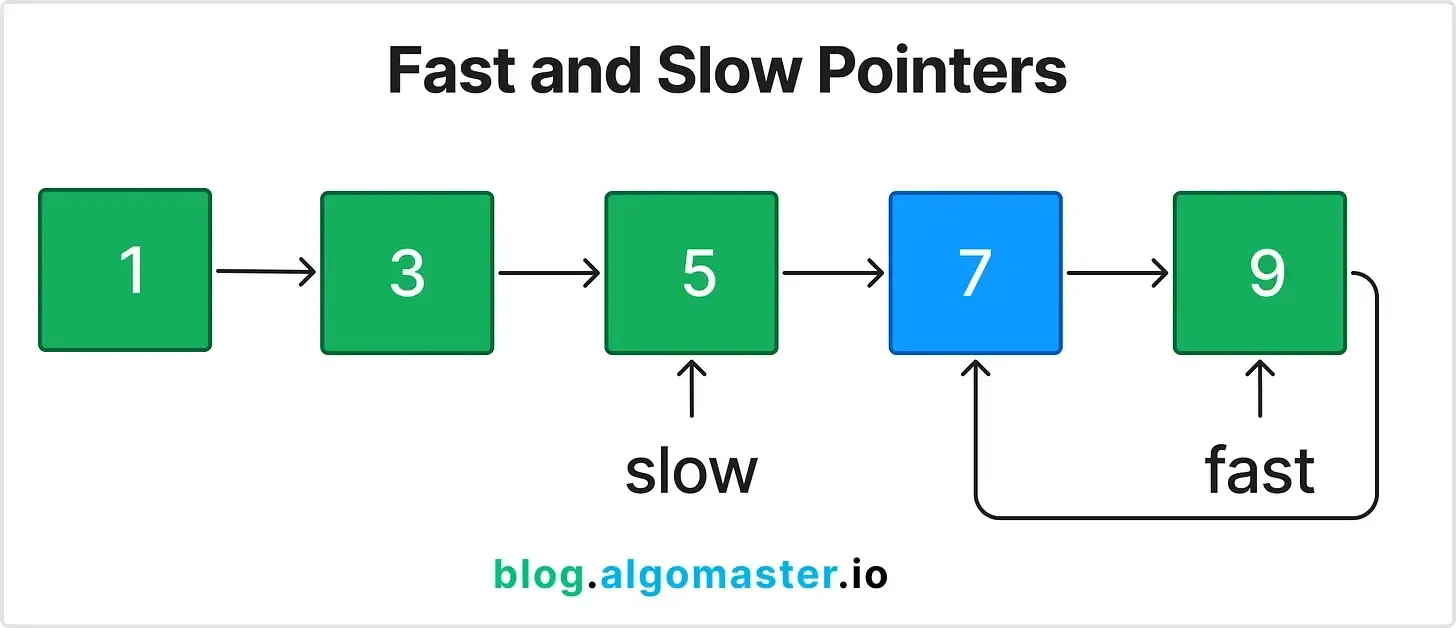

The Fast & Slow Pointers (Tortoise and Hare) pattern is used to detect cycles in linked lists and other similar structures.

Sample Problem:
Detect if a linked list has a cycle.

Explanation:
Initialize two pointers, one moving one step at a time (slow) and the other moving two steps at a time (fast).

If there is a cycle, the fast pointer will eventually meet the slow pointer.

If the fast pointer reaches the end of the list, there is no cycle.

Q. Given head, the head of a linked list, determine if the linked list has a cycle in it.

There is a cycle in a linked list if there is some node in the list that can be reached again by continuously following the next pointer. Internally, pos is used to denote the index of the node that tail's next pointer is connected to. Note that pos is not passed as a parameter.

Return true if there is a cycle in the linked list. Otherwise, return false.

 
- Example 1:

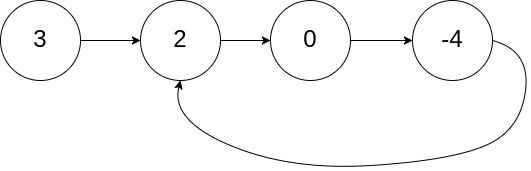

Input: head = [3,2,0,-4], pos = 1
Output: true
Explanation: There is a cycle in the linked list, where the tail connects to the 1st node (0-indexed).

- Example 2:

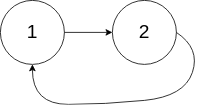

Input: head = [1,2], pos = 0
Output: true
Explanation: There is a cycle in the linked list, where the tail connects to the 0th node.

- Example 3:

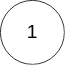

Input: head = [1], pos = -1
Output: false
Explanation: There is no cycle in the linked list.
 

Constraints:

The number of the nodes in the list is in the range [0, 104].
-105 <= Node.val <= 105
pos is -1 or a valid index in the linked-list.
 

Follow up: Can you solve it using O(1) (i.e. constant) memory?

https://leetcode.com/problems/linked-list-cycle/description/

In [ ]:
# Definition for singly-linked list.
# class ListNode:
#     def __init__(self, x):
#         self.val = x
#         self.next = None

class Solution:
    def hasCycle(self, head: Optional[ListNode]) -> bool:
        ptr1 = head
        ptr2 = head
        
        while ptr2 and ptr2.next:
            ptr1 = ptr1.next
            ptr2 = ptr2.next.next

            if ptr1 == ptr2:
                return True
        
        return False

            



Q. Write an algorithm to determine if a number n is happy.

A happy number is a number defined by the following process:

Starting with any positive integer, replace the number by the sum of the squares of its digits.
Repeat the process until the number equals 1 (where it will stay), or it loops endlessly in a cycle which does not include 1.
Those numbers for which this process ends in 1 are happy.
Return true if n is a happy number, and false if not.

 

Example 1:

Input: n = 19
Output: true
Explanation:
12 + 92 = 82
82 + 22 = 68
62 + 82 = 100
12 + 02 + 02 = 1
Example 2:

Input: n = 2
Output: false
 

Constraints:

1 <= n <= 231 - 1

https://leetcode.com/problems/happy-number/description/

In [ ]:
class Solution:
    def isHappy(self, n: int) -> bool:
        if n <= 0:
            return False
        history = {}
        
        while True:
            n_str = str(n)
            t = sum(int(x)**2 for x in n_str)

            if t == 1:
                return True
            if t in history:
                return False

            n = t
            history[t] = True
        
        

Q. Given an array of integers nums containing n + 1 integers where each integer is in the range [1, n] inclusive.

There is only one repeated number in nums, return this repeated number.

You must solve the problem without modifying the array nums and using only constant extra space.

 

Example 1:

Input: nums = [1,3,4,2,2]
Output: 2
Example 2:

Input: nums = [3,1,3,4,2]
Output: 3
Example 3:

Input: nums = [3,3,3,3,3]
Output: 3
 

Constraints:

1 <= n <= 105
nums.length == n + 1
1 <= nums[i] <= n
All the integers in nums appear only once except for precisely one integer which appears two or more times.
 

Follow up:

How can we prove that at least one duplicate number must exist in nums?
Can you solve the problem in linear runtime complexity?

https://leetcode.com/problems/find-the-duplicate-number/description/

In [ ]:
class Solution:
    # O(n) space
    def findDuplicate1(self, nums: List[int]) -> int:
        l = len(nums)
        num_track = {}
        for num in nums:
            if num in num_track:
                return num
            num_track[num] = True
        
        return None

    # O(1) space
    def findDuplicate(self, nums: List[int]) -> int:
        fast = nums[0]
        slow = nums[0]

        # Detects if the loop exists
        while True:
            slow = nums[slow]
            fast = nums[nums[fast]]

            if fast == slow:
                break
        
        # When you reset one pointer and move both at the "same speed", they'll meet exactly at the cycle entrance.
        fast = nums[0]
        while fast != slow:
            fast = nums[fast]
            slow = nums[slow]

        return fast
        

## LinkedList In-place Reversal

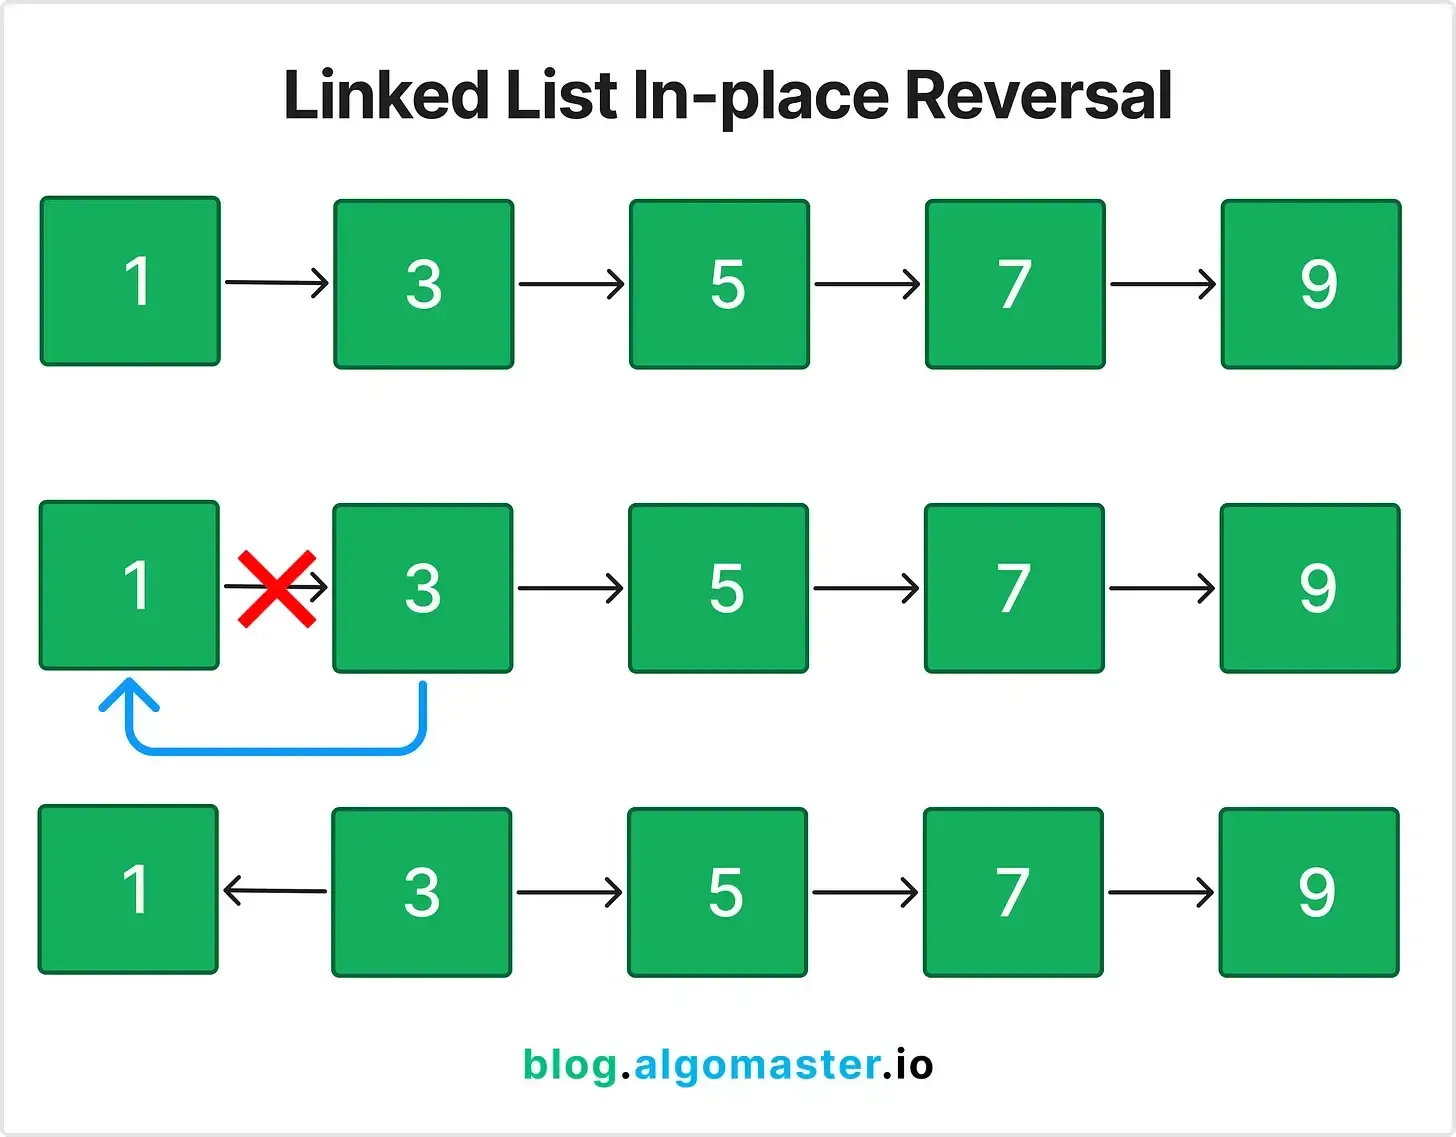

The In-place Reversal of a LinkedList pattern reverses parts of a linked list without using extra space.

Use this pattern when you need to reverse sections of a linked list.

Sample Problem:
Reverse a sublist of a linked list from position m to n.

Example:

Input: head = [1, 2, 3, 4, 5], m = 2, n = 4

Output: [1, 4, 3, 2, 5]

Explanation:
Identify the start and end of the sublist.

Reverse the nodes in place by adjusting the pointers.

Q. Given the head of a singly linked list, reverse the list, and return the reversed list.

 
- Example 1:

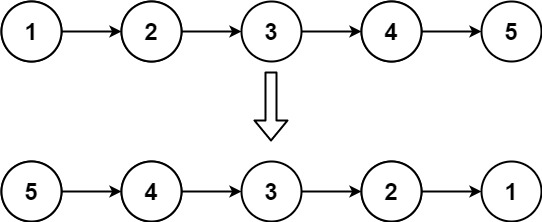

Input: head = [1,2,3,4,5]
Output: [5,4,3,2,1]

- Example 2:

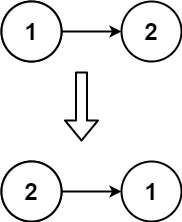

Input: head = [1,2]
Output: [2,1]
Example 3:

Input: head = []
Output: []
 

Constraints:

The number of nodes in the list is the range [0, 5000].
-5000 <= Node.val <= 5000
 

Follow up: A linked list can be reversed either iteratively or recursively. Could you implement both?

In [ ]:
class Solution:

    def reverseList(self, head: Optional[ListNode]) -> Optional[ListNode]:
        if not head:
            return head

        prev = None
        curr = head
        while curr.next is not None:
            tmp = curr.next
            curr.next = prev
            prev = curr
            curr = tmp
        
        curr.next = prev

        return curr
        

            

Q. Given the head of a singly linked list and two integers left and right where left <= right, reverse the nodes of the list from position left to position right, and return the reversed list.

 
Example 1:

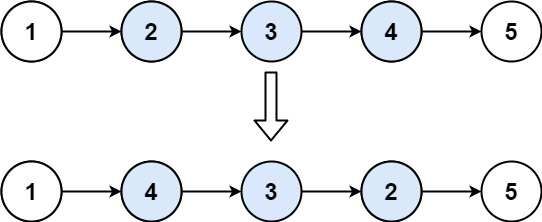

Input: head = [1,2,3,4,5], left = 2, right = 4
Output: [1,4,3,2,5]
Example 2:

Input: head = [5], left = 1, right = 1
Output: [5]
 

Constraints:

The number of nodes in the list is n.
1 <= n <= 500
-500 <= Node.val <= 500
1 <= left <= right <= n
 

Follow up: Could you do it in one pass?

In [ ]:
# Definition for singly-linked list.
# class ListNode:
#     def __init__(self, val=0, next=None):
#         self.val = val
#         self.next = next
class Solution:
    def reverseBetween(self, head: Optional[ListNode], left: int, right: int) -> Optional[ListNode]:
        
        if not head or left == right:
            return head

        i = 1
        start = None
        curr = head
        while i < left:
            start, curr = curr, curr.next
            i += 1
        
        rev_start = curr
        prev = None
        curr = rev_start
        tmp = curr.next
        
        while i < right:
            tmp = curr.next
            curr.next = prev
            prev = curr
            curr = tmp
            i += 1
        
        if left > 1:
            start.next = curr

        rev_start.next = curr.next
        curr.next = prev

        return curr if left == 1 else head

        

        

Q. Given a linked list, swap every two adjacent nodes and return its head. You must solve the problem without modifying the values in the list's nodes (i.e., only nodes themselves may be changed.)

 

Example 1:

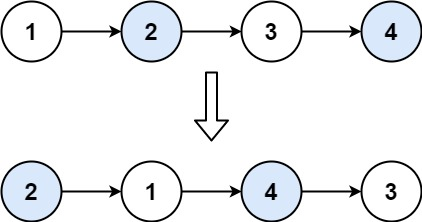

Input: head = [1,2,3,4]

Output: [2,1,4,3]

Explanation:



Example 2:

Input: head = []

Output: []

Example 3:

Input: head = [1]

Output: [1]

Example 4:

Input: head = [1,2,3]

Output: [2,1,3]

 

Constraints:

The number of nodes in the list is in the range [0, 100].
0 <= Node.val <= 100

https://leetcode.com/problems/swap-nodes-in-pairs/description/

In [ ]:
# Definition for singly-linked list.
# class ListNode:
#     def __init__(self, val=0, next=None):
#         self.val = val
#         self.next = next
class Solution:
    def swapPairs(self, head: Optional[ListNode]) -> Optional[ListNode]:
        if not head or not head.next:
            return head

        prev = head
        curr = head.next

        i = 0

        while prev.next is not None:
            tmp = curr.next
            
            if i == 0:
                head = curr

            if tmp is None:
                prev.next = None
                curr.next = prev
                return head
            elif tmp.next is None: 
                prev.next = tmp
                curr.next = prev
                return head
            else:
                prev.next = tmp.next

            curr.next = prev

            prev = tmp
            curr = tmp.next

            i += 1
        
        return head
            
        

## Monotonic Stack

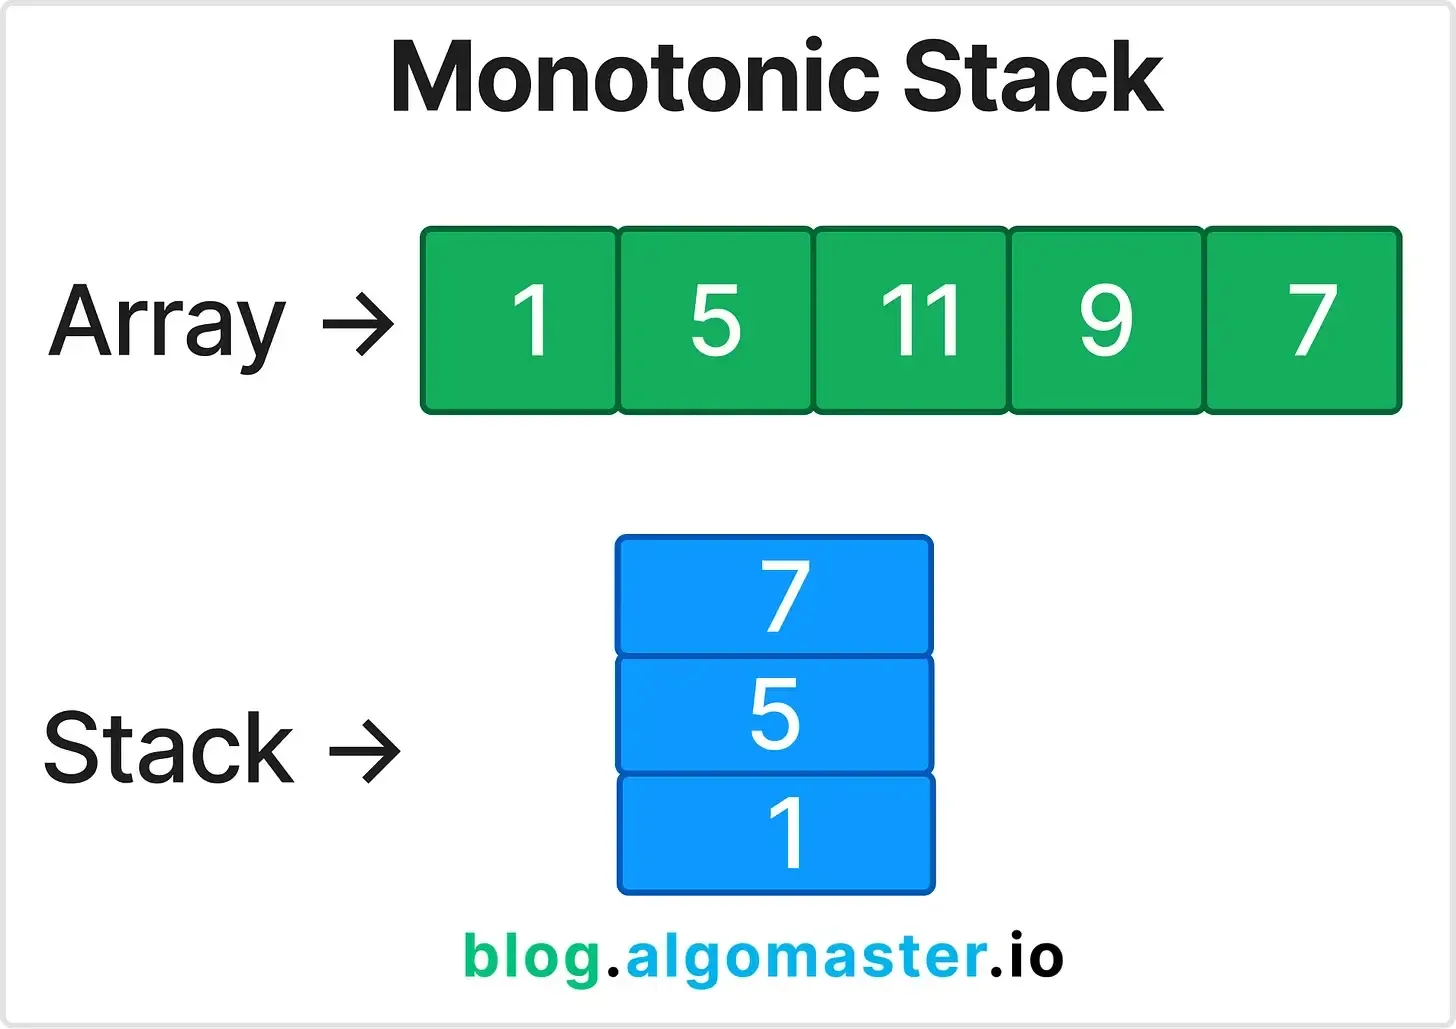

The Monotonic Stack pattern uses a stack to maintain a sequence of elements in a specific order (increasing or decreasing).

Use this pattern for problems that require finding the next greater or smaller element.

Sample Problem:
Find the next greater element for each element in an array. Output -1 if the greater element doesn’t exist.

Example:

Input: nums = [2, 1, 2, 4, 3]

Output: [4, 2, 4, -1, -1]

Explanation:
Use a stack to keep track of elements for which we haven't found the next greater element yet.

Iterate through the array, and for each element, pop elements from the stack until you find a greater element.

If the stack is not empty, set the result for index at the top of the stack to current element.

Push the current element onto the stack.

In [ ]:
def nextGreaterElement(nums):
    n = len(nums)
    result = [-1] * n
    stack = []  # stores indices
    
    for i in range(n):
        # Pop smaller elements - they found their next greater!
        while stack and nums[stack[-1]] < nums[i]:
            idx = stack.pop()
            result[idx] = nums[i]
        stack.append(i)
    
    return result

In [ ]:
a = [2, 1, 2, 4, 3]
nextGreaterElement(a)

Q. The next greater element of some element x in an array is the first greater element that is to the right of x in the same array.

You are given two distinct 0-indexed integer arrays nums1 and nums2, where nums1 is a subset of nums2.

For each 0 <= i < nums1.length, find the index j such that nums1[i] == nums2[j] and determine the next greater element of nums2[j] in nums2. If there is no next greater element, then the answer for this query is -1.

Return an array ans of length nums1.length such that ans[i] is the next greater element as described above.

 

Example 1:

Input: nums1 = [4,1,2], nums2 = [1,3,4,2]
Output: [-1,3,-1]
Explanation: The next greater element for each value of nums1 is as follows:
- 4 is underlined in nums2 = [1,3,4,2]. There is no next greater element, so the answer is -1.
- 1 is underlined in nums2 = [1,3,4,2]. The next greater element is 3.
- 2 is underlined in nums2 = [1,3,4,2]. There is no next greater element, so the answer is -1.
Example 2:

Input: nums1 = [2,4], nums2 = [1,2,3,4]
Output: [3,-1]
Explanation: The next greater element for each value of nums1 is as follows:
- 2 is underlined in nums2 = [1,2,3,4]. The next greater element is 3.
- 4 is underlined in nums2 = [1,2,3,4]. There is no next greater element, so the answer is -1.
 

Constraints:

1 <= nums1.length <= nums2.length <= 1000
0 <= nums1[i], nums2[i] <= 104
All integers in nums1 and nums2 are unique.
All the integers of nums1 also appear in nums2.
 

Follow up: Could you find an O(nums1.length + nums2.length) solution?

https://leetcode.com/problems/next-greater-element-i/description/

In [ ]:
class Solution:
    def nextGreaterElement1(self, nums1: List[int], nums2: List[int]) -> List[int]:
        res = []
        for i, n1 in enumerate(nums1):
            found = False
            for j, n2 in enumerate(nums2):
                if n1 == n2:
                    sub_nums2 = nums2[j:]
                    for sn2 in sub_nums2:
                        if sn2 > n2:
                            res.append(sn2)
                            found = True
                            break
                    else:
                        res.append(-1)
                        found = True
                        break
            if not found:
                res.append(-1)

        return res
    
    def nextGreaterElement(self, nums1: List[int], nums2: List[int]) -> List[int]:
        num2_idx_map = {}
        for i, num2 in enumerate(nums2):
            # as all elements are unique
            num2_idx_map[num2] = i

        res = []
        for num1 in nums1:
            nums2_idx = num2_idx_map[num1]
            for num2 in nums2[nums2_idx:]:
                if num2 > num1:
                    res.append(num2)
                    break
            else:
                res.append(-1)
        
        return res        

        

Q. Given an array of integers temperatures represents the daily temperatures, return an array answer such that answer[i] is the number of days you have to wait after the ith day to get a warmer temperature. If there is no future day for which this is possible, keep answer[i] == 0 instead.

 

Example 1:

Input: temperatures = [73,74,75,71,69,72,76,73]
Output: [1,1,4,2,1,1,0,0]
Example 2:

Input: temperatures = [30,40,50,60]
Output: [1,1,1,0]
Example 3:

Input: temperatures = [30,60,90]
Output: [1,1,0]
 

Constraints:

1 <= temperatures.length <= 105
30 <= temperatures[i] <= 100

https://leetcode.com/problems/daily-temperatures/description/

In [ ]:
class Solution:
    def dailyTemperatures(self, temperatures: List[int]) -> List[int]:
        n = len(temperatures)
        res = [0] * n
        stack = []
        # counter = {}

        for i in range(n):
            # counter[i] = 0
            while stack and temperatures[stack[-1]] < temperatures[i]:
                idx = stack.pop()
                res[idx] = (i - idx)
            stack.append(i)
        return res

Q. Given an array of integers heights representing the histogram's bar height where the width of each bar is 1, return the area of the largest rectangle in the histogram.

Example 1:

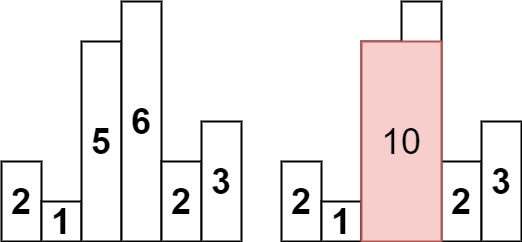

Input: heights = [2,1,5,6,2,3]
Output: 10
Explanation: The above is a histogram where width of each bar is 1.
The largest rectangle is shown in the red area, which has an area = 10 units.
Example 2:

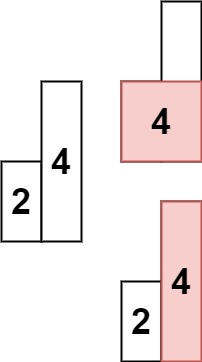

Input: heights = [2,4]
Output: 4
 

Constraints:

1 <= heights.length <= 105
0 <= heights[i] <= 104

https://leetcode.com/problems/largest-rectangle-in-histogram/description/

In [ ]:
class Solution:
    def largestRectangleArea(self, heights: List[int]) -> int:
        """
        To find the largest rectangle in a histogram, for each bar we want to determine:

        How far left and right the rectangle can extend while being at least as tall as the current bar.
        This means we need the Previous Smaller Element (PSE) and the Next Smaller Element (NSE) for each bar.
        Using a stack helps efficiently compute this during a single pass.
        """
        n = len(heights)
        max_area = heights[0]
        max_h = [heights[0], 0]
        min_h = [heights[0], 0]
        prev_smaller_vals = [-1] * n
        next_smaller_vals = [-1] * n
        stack = []
        
        
        for i in range(n):
            while stack and heights[i] < heights[stack[-1]]:
                idx = stack.pop()
                next_smaller_vals[idx] = i
            stack.append(i)
        
        print(next_smaller_vals)
        
        stack = []
        for i in range(n - 1, -1, -1):
            while stack and heights[i] < heights[stack[-1]]:
                idx = stack.pop()
                prev_smaller_vals[idx] = i
            stack.append(i)
        
        print(prev_smaller_vals)

        max_area = 0
        for i in range(n):
            h = heights[i]
            prev_smaller_idx = prev_smaller_vals[i]
            next_smaller_idx = next_smaller_vals[i]
            right = (n - i) if next_smaller_idx == -1 else (next_smaller_idx - i)
            left = i if prev_smaller_idx == -1 else (i - (prev_smaller_idx + 1))
            area = h * (right + left)
            max_area = max(max_area, area)

        return max_area

Q. Given n non-negative integers representing an elevation map where the width of each bar is 1, compute how much water it can trap after raining.


Example 1:

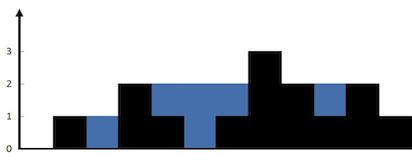

Input: height = [0,1,0,2,1,0,1,3,2,1,2,1]
Output: 6
Explanation: The above elevation map (black section) is represented by array [0,1,0,2,1,0,1,3,2,1,2,1]. In this case, 6 units of rain water (blue section) are being trapped.
Example 2:

Input: height = [4,2,0,3,2,5]
Output: 9
 

Constraints:

n == height.length
1 <= n <= 2 * 104
0 <= height[i] <= 105

https://leetcode.com/problems/trapping-rain-water/

In [ ]:
class Solution:
    def trap(self, height: List[int]) -> int:
        n = len(height)
        l = 0
        r = (n -1)
        l_max = height[l]
        r_max = height[r]
        water = 0

        while l < r:
            if l_max < r_max:
                l += 1
                l_max = max(l_max, height[l])
                water += (l_max - height[l])
            else:
                r -= 1
                r_max = max(r_max, height[r])
                water += (r_max - height[r])
        
        return water

        

Q. Design an algorithm that collects daily price quotes for some stock and returns the span of that stock's price for the current day.

The span of the stock's price in one day is the maximum number of consecutive days (starting from that day and going backward) for which the stock price was less than or equal to the price of that day.

For example, if the prices of the stock in the last four days is [7,2,1,2] and the price of the stock today is 2, then the span of today is 4 because starting from today, the price of the stock was less than or equal 2 for 4 consecutive days.
Also, if the prices of the stock in the last four days is [7,34,1,2] and the price of the stock today is 8, then the span of today is 3 because starting from today, the price of the stock was less than or equal 8 for 3 consecutive days.
Implement the StockSpanner class:

StockSpanner() Initializes the object of the class.
int next(int price) Returns the span of the stock's price given that today's price is price.
 

Example 1:

Input
["StockSpanner", "next", "next", "next", "next", "next", "next", "next"]
[[], [100], [80], [60], [70], [60], [75], [85]]
Output
[null, 1, 1, 1, 2, 1, 4, 6]

Explanation
StockSpanner stockSpanner = new StockSpanner();
stockSpanner.next(100); // return 1
stockSpanner.next(80);  // return 1
stockSpanner.next(60);  // return 1
stockSpanner.next(70);  // return 2
stockSpanner.next(60);  // return 1
stockSpanner.next(75);  // return 4, because the last 4 prices (including today's price of 75) were less than or equal to today's price.
stockSpanner.next(85);  // return 6
 

Constraints:

1 <= price <= 105
At most 104 calls will be made to next.

https://leetcode.com/problems/online-stock-span/description/

In [ ]:
class StockSpanner:

    def __init__(self):
        self.prices = []
        self.stack = []
        self.idx = 0
        # self.next_max_price = []

    def next1(self, price: int) -> int:
        self.prices.append(price)
        span = 0
        for i in range(len(self.prices)-1, -1, -1):
            if self.prices[i] <= price:
                span += 1
            else:
                break

        return span
    
    def next(self, price: int) -> int:
        span = 1
        while self.stack and self.prices[self.stack[-1][0]] <= price:
            idx = self.stack.pop()
            # self.next_max_price[idx[0]] = price
            span += idx[1]
        self.prices.append(price)
        self.stack.append([self.idx, span])
        # self.next_max_price.append(None)
        self.idx += 1

        return span


# Your StockSpanner object will be instantiated and called as such:
# obj = StockSpanner()
# param_1 = obj.next(price)

## Bit Manipulation

Bit manipulation uses binary operations (AND, OR, XOR, NOT, shifts) to solve problems efficiently. XOR is particularly useful since a ^ a = 0 and a ^ 0 = a.

When to use
Finding unique numbers (XOR)

Checking power of 2

Counting bits

Generating subsets using bit masks

Space optimization

In [ ]:
// Basic operations
int and = a & b;        // both bits 1
int or = a | b;         // either bit 1
int xor = a ^ b;        // bits different
int not = ~a;           // flip bits
int leftShift = a << n; // multiply by 2^n
int rightShift = a >> n;// divide by 2^n

// Check if bit i is set
boolean isSet = (n & (1 << i)) != 0;

// Set bit i
n = n | (1 << i);

// Clear bit i
n = n & ~(1 << i);

// Toggle bit i
n = n ^ (1 << i);

// Check if power of 2
boolean isPowerOf2 = (n > 0) && ((n & (n - 1)) == 0);

// Count set bits
int count = 0;
while (n > 0) {
    count += n & 1;
    n >>= 1;
}
// Or: Integer.bitCount(n);

// Find single number (XOR all elements)
int single = 0;
for (int num : nums) {
    single ^= num;
}

Q. Given a non-empty array of integers nums, every element appears twice except for one. Find that single one.

You must implement a solution with a linear runtime complexity and use only constant extra space.

 

Example 1:

Input: nums = [2,2,1]

Output: 1

Example 2:

Input: nums = [4,1,2,1,2]

Output: 4

Example 3:

Input: nums = [1]

Output: 1

 

Constraints:

1 <= nums.length <= 3 * 104
-3 * 104 <= nums[i] <= 3 * 104
Each element in the array appears twice except for one element which appears only once.

https://leetcode.com/problems/single-number/description/

In [ ]:
class Solution:
    def singleNumber(self, nums: List[int]) -> int:
        '''
        If there are duplicates for all elemenets then the final value of XOR should be 0. 
        So if 1 does not have a duplicate, the final value of XOR should be that number itself (as x ^ x = 0, so x ^ 0 = x).
        '''
        single = 0
        for num in nums:
            single ^= num
        
        return single
        

Q. Given a positive integer n, write a function that returns the number of set bits in its binary representation (also known as the Hamming weight).

 

Example 1:

Input: n = 11

Output: 3

Explanation:

The input binary string 1011 has a total of three set bits.

Example 2:

Input: n = 128

Output: 1

Explanation:

The input binary string 10000000 has a total of one set bit.

Example 3:

Input: n = 2147483645

Output: 30

Explanation:

The input binary string 1111111111111111111111111111101 has a total of thirty set bits.

 

Constraints:

1 <= n <= 231 - 1
 

Follow up: If this function is called many times, how would you optimize it?

https://leetcode.com/problems/number-of-1-bits/description/

In [ ]:
class Solution:
    def hammingWeight(self, n: int) -> int:
        count = 0
        while n > 0:
            count += n & 1  # check if the last bit is 1
            n = n >> 1  # right shift the number by 1 place (divide by 2)

        return count 

Q. Given an integer n, return an array ans of length n + 1 such that for each i (0 <= i <= n), ans[i] is the number of 1's in the binary representation of i.

 

Example 1:

Input: n = 2
Output: [0,1,1]
Explanation:
0 --> 0
1 --> 1
2 --> 10
Example 2:

Input: n = 5
Output: [0,1,1,2,1,2]
Explanation:
0 --> 0
1 --> 1
2 --> 10
3 --> 11
4 --> 100
5 --> 101
 

Constraints:

0 <= n <= 105
 

Follow up:

It is very easy to come up with a solution with a runtime of O(n log n). Can you do it in linear time O(n) and possibly in a single pass?
Can you do it without using any built-in function (i.e., like __builtin_popcount in C++)?

https://leetcode.com/problems/counting-bits/description/

In [ ]:
class Solution:
    def countBitsOneNumber(self, n: int):
        count = 0
        while n > 0:
            count += n & 1
            n = n >> 1
        return count

    def countBits(self, n: int) -> List[int]:
        return [self.countBitsOneNumber(x) for x in range(n + 1)]

Q. Given an integer n, return true if it is a power of two. Otherwise, return false.

An integer n is a power of two, if there exists an integer x such that n == 2x.

 

Example 1:

Input: n = 1
Output: true
Explanation: 20 = 1
Example 2:

Input: n = 16
Output: true
Explanation: 24 = 16
Example 3:

Input: n = 3
Output: false
 

Constraints:

-231 <= n <= 231 - 1
 

Follow up: Could you solve it without loops/recursion?

https://leetcode.com/problems/power-of-two/description/

In [ ]:
class Solution:
    def isPowerOfTwo2(self, n: int) -> bool:
        while True:
            if n == 1:
                return True
            
            if n < 1:
                return False
            
            n /= 2
    
    def isPowerOfTwo(self, n: int) -> bool:
        return (n > 0) and n & (n -1) == 0
            


Q. Given an array nums containing n distinct numbers in the range [0, n], return the only number in the range that is missing from the array.

 

Example 1:

Input: nums = [3,0,1]

Output: 2

Explanation:

n = 3 since there are 3 numbers, so all numbers are in the range [0,3]. 2 is the missing number in the range since it does not appear in nums.

Example 2:

Input: nums = [0,1]

Output: 2

Explanation:

n = 2 since there are 2 numbers, so all numbers are in the range [0,2]. 2 is the missing number in the range since it does not appear in nums.

Example 3:

Input: nums = [9,6,4,2,3,5,7,0,1]

Output: 8

Explanation:

n = 9 since there are 9 numbers, so all numbers are in the range [0,9]. 8 is the missing number in the range since it does not appear in nums.

Constraints:

n == nums.length
1 <= n <= 104
0 <= nums[i] <= n
All the numbers of nums are unique.
 

Follow up: Could you implement a solution using only O(1) extra space complexity and O(n) runtime complexity?

https://leetcode.com/problems/missing-number/description/

In [ ]:
class Solution:
    def missingNumber1(self, nums: List[int]) -> int:
        n = len(nums) + 1
        expected_sum = n * (0 + n - 1) / 2
        curr_sum = sum(nums)

        return int(expected_sum - curr_sum)

    def missingNumber(self, nums: List[int]) -> int:
        n = len(nums) + 1
        count = 0
        for num in nums:
            count ^= num

        for num in range(n):
            count ^= num
        
        return count

(1, 2)

## Top ‘K’ Elements

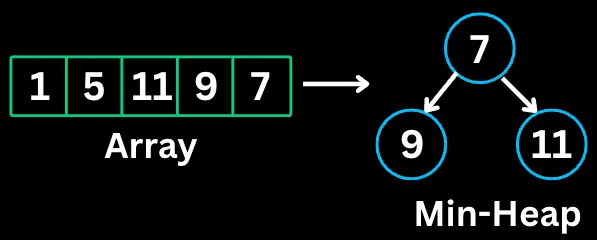

This pattern finds the k largest or smallest elements using heaps (priority queues). A min-heap of size k keeps track of k largest elements, and a max-heap keeps k smallest.

When to use
Finding k largest/smallest elements

Finding kth largest/smallest element

Finding k most/least frequent elements

Merging k sorted lists

Template
// K largest elements using min-heap
PriorityQueue<Integer> minHeap = new PriorityQueue<>();

for (int num : nums) {
    minHeap.offer(num);
    if (minHeap.size() > k) {
        minHeap.poll(); // remove smallest
    }
}
// minHeap now contains k largest elements
// minHeap.peek() is the kth largest
Sample Problem
Kth Largest Element: Find the kth largest element in an unsorted array.

Example:
Input: nums = [3, 2, 1, 5, 6, 4], k = 2

Output: 5

Step-by-Step Walkthrough:
nums = [3, 2, 1, 5, 6, 4], k = 2
Using min-heap of size k

Step 1: num = 3
  heap = [3]

Step 2: num = 2
  heap = [2, 3]

Step 3: num = 1
  heap = [1, 3, 2], size > k
  poll smallest: heap = [2, 3]

Step 4: num = 5
  heap = [2, 3, 5], size > k
  poll smallest: heap = [3, 5]

Step 5: num = 6
  heap = [3, 5, 6], size > k
  poll smallest: heap = [5, 6]

Step 6: num = 4
  heap = [4, 6, 5], size > k
  poll smallest: heap = [5, 6]

heap.peek() = 5 (kth largest)